# <a id='toc1_'></a>[Bericht zur Datenqualität (epi2025_beta) 📉](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität (epi2025_beta) 📉](#toc1_)    
  - [Änderungen seit der letzten Version](#toc1_1_)    
  - [Hinweise](#toc1_2_)    
  - [Datenstand 🕥](#toc1_3_)    
  - [Fallzahlen im Verlauf der Jahreslieferungen](#toc1_4_)    
    - [original geliefert](#toc1_4_1_)    
    - [nach Abschluss der Prüfungen im ZfKD](#toc1_4_2_)    
  - [Variablenverteilung](#toc1_5_)    
    - [Diagnosejahr](#toc1_5_1_)    
    - [Diagnosegruppen](#toc1_5_2_)    
    - [Diagnosesicherung](#toc1_5_3_)    
    - [DCO Diagramm](#toc1_5_4_)    
    - [DCO Tabelle](#toc1_5_5_)    
    - [Anteil Mehrfachtumore](#toc1_5_6_)    
    - [Dignität](#toc1_5_7_)    
    - [Grading 1](#toc1_5_8_)    
    - [Grading 2](#toc1_5_9_)    
    - [Altersgruppen](#toc1_5_10_)    
    - [TNM](#toc1_5_11_)    
    - [UICC](#toc1_5_12_)    
    - [TNM-Auflage](#toc1_5_13_)    
    - [Tod](#toc1_5_14_)    
      - [Verteilung der Variable TOD im verarbeiteten Datensatz](#toc1_5_14_1_)    
      - [Verteilung der Variable TOD in den original gelieferten Daten](#toc1_5_14_2_)    
    - [Verteilung Todesursachen nach ICDT10](#toc1_5_15_)    
  - [Plausibilitätsprüfungen](#toc1_6_)    
    - [ ⚠️ 01-SH](#toc1_6_1_)    
    - [✅ 02-HH](#toc1_6_2_)    
    - [✅ 03-NI](#toc1_6_3_)    
    - [✅ 04-HB](#toc1_6_4_)    
    - [⚠️ 05-NW](#toc1_6_5_)    
    - [🚨 06-HE](#toc1_6_6_)    
    - [✅ 07-RP](#toc1_6_7_)    
    - [✅ 08-BW](#toc1_6_8_)    
    - [✅ 09-BY](#toc1_6_9_)    
    - [⚠️ 10-SL](#toc1_6_10_)    
    - [✅ 11-GKR (ehemals)](#toc1_6_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Änderungen seit der letzten Version](#toc0_)
<!-- - bisher wurden folgende Angaben in einer umfangreichen Verarbeitung im workflow umkodiert: `ICDGM10`, `HISC`, `ICDO3`, `DIG`. Diese Umformung wurde deaktiviert, es finden nun nur noch punktuelle Korrekturen statt -->
- Lieferung Daten mit DJ=2024

<br>

## <a id='toc1_2_'></a>[Hinweise](#toc0_)
- Bewertungen der Analysen sind mit 💡 markiert
- bei den Plausibilitätsprüfungen weist ein ✅ darauf hin, dass keine Mängel erkennbar sind

<br>

## <a id='toc1_3_'></a>[Datenstand 🕥](#toc0_)

In [1]:

import os
from pathlib import Path
import pandas as pd
import datetime as dt
from pandas_plots import tbl, pls, hlp
import duckdb as ddb

from connection_helper import sql
import numpy as np

hlp.show_package_version()

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

# file_epi = dir_db/'2025-11-06_data_epi.duckdb'
# file_meta = dir_db/'2025-11-06_meta_epi.duckdb'
file_epi = dir_db/'2026-02-20_data_epi.duckdb'
file_meta = dir_db/'2026-02-20_meta_epi.duckdb'

if not file_epi.exists() or not file_meta.exists():
    raise Exception(f"files {file_epi} or {file_meta} not found")

URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

os.environ['THEME']='light'
os.environ['RENDERER']='svg'

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.4 | 📦 connection-helper: 0.13.3


In [2]:
sql.print_meta(file_epi)

database file:           2026-02-20_data_epi.duckdb
data tag:                epi2025_beta
sql table created:       2026-02-20 08:20:43
doi:                     -
document created:        2026-02-27 12:22:15


In [3]:
_=con = ddb.connect()
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_epi}' AS epi (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_meta}' AS meta (READ_ONLY); set schema 'epi';")

In [4]:
# todo add dim tables to epi duckdb

dim_dig = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/dig.csv", sep=";")
# dim_dsich_clin = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/diagnosesicherung_clin.csv", sep=";")
dim_dsich_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/diagnosesicherung_epi.csv", sep=";")
# dim_grading_clin = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/grading_clin.csv", sep=";")
dim_grading_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/grading_epi.csv", sep=";")
# dim_icd10 = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/icd10.csv", sep=";")
# dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
# dim_landkreis = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/landkreis.csv", sep=";")
dim_lieferregister = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/lieferregister.csv", sep=";")
dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
# dim_op_intention = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/op_intention.csv", sep=";")
# dim_tnm_t = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/tnm_t.csv", sep=";")
# dim_tnm_uicc = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/tnm_uicc.csv", sep=";")

dim_tree = sql.load_file_to_duckdb(con, "../../src/quality-reports/data/dim_tree.csv", sep=";")

dim_lieferregister_= dim_lieferregister.to_df().set_index('code').replace({"11-BE":"11-GKR"})
dim_dsich_epi = dim_dsich_epi.to_df().assign(label=lambda x: x['code'].astype(str)+ ' - ' + x['name']).set_index('code')
dim_dig = dim_dig.to_df().assign(label=lambda x: x['code'].astype(str) + ' - ' + x['name']).set_index('code')
dim_grading_epi = dim_grading_epi.to_df().assign(label=lambda x: x['code'].astype(str) + ' - ' + x['name']).set_index('code')

In [5]:
Batches = con.sql("select * from meta.Batches;")
Checks = con.sql("select * from meta.Checks;")
ColumnCheck = con.sql("select * from meta.ColumnCheck;")
Frequencies = con.sql("select * from meta.Frequencies;")
# _meta_meta = con.sql("select * from meta._meta;")

df_checks = Checks.to_df().astype({"EKRNR": str})
df_freqs = (
    Frequencies.project(
        "*, concat(cast(BatchID as varchar),' | ', cast(cast(BatchZeit as date) as varchar)) as batch_label"
    )
    .to_df()
    .astype({"EKRNR": str})
)
df_freqs["EKRNR"] = df_freqs["EKRNR"].astype(int).replace(dim_lieferregister_["kkr"].to_dict())
df_checks["EKRNR"] = df_checks["EKRNR"].astype(int).replace(dim_lieferregister_["kkr"].to_dict())
df_batches= Batches.to_df()
df_columnchecks= ColumnCheck.to_df().set_index('ColumnCheckID')
df_checks = df_checks.join(df_columnchecks, on='ColumnCheckID')
df_checks["check_label"] = df_checks.apply(lambda x: f"{x['Alias']}[{x['ColumnCheckID']}]", axis=1)
df_checks= df_checks[["EKRNR","Anzahl","BatchID","DJahr","check_label","ColumnCheckID"]]

In [6]:
db_epi = con.sql("select * from Tumor4;").project("*, left(ICDGM10,3) as z_icd10_3d")

In [7]:
batch_max=df_checks['BatchID'].max()
batch_list = [batch_max,418,416,399,360]
batch_min=399
db_list_dy="(2024)"    # must be a str list, since "alt" is in dy col - or a ddb compatible str

In [8]:
print(f"\n{'letzter batch': <32}{batch_max}")
print(f"{'inkludierte Diagnosejahre 📆': <30} {db_list_dy}")


letzter batch                   422
inkludierte Diagnosejahre 📆    (2024)


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Fallzahlen im Verlauf der Jahreslieferungen](#toc0_)
- kein Filter
- es werden Datenstände (_batch_) aus mehreren Lieferjahren dargestellt , welche über eine laufende Nummer sowie das Datum der Ausführung vergleichbar sind
- in Abgrenzung zu den klinischen Daten ist jede einzelne EKR Lieferung für das gesamte Lieferjahr gültig

<br>

### <a id='toc1_4_1_'></a>[original geliefert](#toc0_)
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **vor** den ZfKD Anpassungen
- `batch_label` markiert den jeweils letzten offiziellen Datenstand des Lieferjahres, sowie den aktuellen Datenstand

In [9]:
# from tkinter import font


_df=df_freqs[(df_freqs.Stufe==2) & (df_freqs.Alias=="SEX") & (df_freqs.BatchID.isin(batch_list))]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(
    _df,
    total_axis="y",
    data_bar_axis="x",
    font_size_th=13,
    font_size_td=11,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,624_239,371_807,1_545_623,132_265,2_906_452,782_871,632_930,766_070,1_535_587,360_943,3_605_815,13_264_602
399 | 2024-12-02,734_305,423_109,1_816_413,151_753,3_991_177,918_534,823_343,1_048_203,1_811_372,400_646,3_792_956,15_911_811
416 | 2025-04-01,780_626,445_714,1_911_528,157_932,4_186_192,958_031,863_935,1_152_455,1_916_313,412_559,3_974_287,16_759_572
418 | 2025-06-20,780_626,445_714,1_911_528,157_932,4_186_192,973_597,863_935,1_152_455,1_916_313,412_559,3_950_260,16_751_111
422 | 2026-02-20,824_131,462_565,2_007_107,162_936,4_404_285,1_010_507,903_789,1_259_176,2_030_094,429_016,nan,13_493_606


<br>

### <a id='toc1_4_2_'></a>[nach Abschluss der Prüfungen im ZfKD](#toc0_)
- Filter: jeweils das **letzte DJ** der einzelnen Jahreslieferung
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **nach** den ZfKD Anpassungen

In [10]:
_df=df_freqs[
    (df_freqs.Stufe==5) & 
    (df_freqs.Alias=="SEX") & 
    (df_freqs.BatchID.isin(batch_list))
    & (df_freqs.DJahr!="alt")
    ]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(_df, total_axis="y", data_bar_axis="x", font_size_th=13,font_size_td=11,)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,32_401,17_099,81_092,6_548,176_210,38_279,25_194,77_968,85_001,11_391,164_812,715_995
399 | 2024-12-02,33_243,18_238,85_016,6_086,193_412,38_294,28_779,78_883,80_929,11_665,162_633,737_178
416 | 2025-04-01,34_512,18_011,86_331,5_068,202_655,30_291,30_000,81_600,84_717,11_076,157_970,742_231
418 | 2025-06-20,34_512,18_011,86_331,5_068,202_655,44_073,30_000,81_320,84_717,11_076,155_450,753_213
422 | 2026-02-20,36_307,17_987,84_692,4_687,191_487,31_633,31_489,82_957,86_674,12_247,nan,580_160


In [11]:
# # * internal check
# _df=(df_checks[(df_checks.ColumnCheckID==48) & (df_checks.BatchID >= batch_min) & (df_checks.BatchID != 415)].sort_values('BatchID'))
# _df=_df.pivot_table(index="BatchID", columns="EKRNR", values="Anzahl", aggfunc="sum").fillna(0)
# tbl.show_num_df(_df, total_axis="y", data_bar_axis="x")

<div style="page-break-after: always;"></div>

## <a id='toc1_5_'></a>[Variablenverteilung](#toc0_)
<!-- - **Filter:**
  - **🚨 sofern nicht anders angegeben ist der Zeitraum beschränkt auf das höchste Diagnosejahr (für `epi2024`: 2023) 🚨**
  - Diagnosen: ausgeschlossen sind `C44` und alle `D` -->
- ab hier wird nur die aktuelle Datenlieferung dargestellt
- als ungültig markierte Fälle (_A-Prüfungen_) sind in allen Fallzahlen ausgeschlossen
- in den barplots sind die relativen Häufigkeiten von Variablen im Datensatz der Register aufgetragen
- zusätzlich ist die Angabe für alle kkr enthalten (`Total`)
- näherungsweise sind GKZ-Bundesländer verwendet anstatt Lieferregister, um 11-16 aufspannen zu können

In [12]:
def show_freqs_batch(df: pd.DataFrame, batch: int, alias: str, current_only: bool = False) -> None:
    if current_only:
        df=df[df['DJahr'] != 'alt']
    df=df.loc[
        (df['BatchID'] == batch)
        & (df['Alias'] == alias)
        & (df['Stufe'] == 5)
        ,['EKRNR','Wert','Anzahl']]
    return df
    # pls.plot_stacked_bars(df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=f'{alias} {batch_max}', show_total=True)

# print(f"Mögliche Variablen für Auswertung: \n{df_freqs.Alias.unique()}")
_aliases=['DJ','DSICH','DCO','DIG','GRAD','ALTGRP', 'UICC','TNMAUFL', 'TOD','GKZAUFL']

# ! switch from ekr -> bl
# print(f"{np.array(db_epi.columns)}")
def show_freqs(alias: str, db_list_dy: str = db_list_dy, incl_c44_and_d = False)-> None:
    df = db_epi
    if not incl_c44_and_d:
        df = (df
                .filter("""--sql
                    left(ICDGM10,3) != 'C44' and left(ICDGM10,1)='C'
                """)
        )
    df = (df
            .filter(f"DJ in {db_list_dy}")
            .filter("GKZbl::int <=16")
            .filter("is_deleted = 0")
            .aggregate(f"GKZbl, {alias}, count(*) as cnt")
            .join(dim_lieferregister, "GKZbl = code", "left")
            .project("* exclude(code)")
            .to_df()
    )

    return df

caption_str=lambda alias, batch_max: f"{alias}"

<br>

### <a id='toc1_5_1_'></a>[Diagnosejahr](#toc0_)
- **Filter: DJ > 2018, C44 und D-Diagnosen sind ausgeschlossen**

In [13]:
# FILTER_NO_C44_D = "left(ICDGM10,3) != 'C44' and left(ICDGM10,1)='C'"

# df = (
#     con.sql(f"""--sql
#         select
#                 DJ,
#                 lief.kkr as lkr,
#                 count(*)::int as cnt
#         from Tumor4 tum
#         left join dim_lieferregister lief on tum.GKZbl = lief.code
#         where is_deleted = 0
#         and DJ > 2018
#         and GKZbl::int8 <= 16
#         and {FILTER_NO_C44_D}
#         group by DJ, kkr
#         """)
#     .to_df()
# )
# print(df)

In [14]:
_df=show_freqs(alias="DJ", db_list_dy="(2019,2020,2021,2022,2023,2024,2025)", incl_c44_and_d=False).pivot_table(index="DJ", columns="kkr", values="cnt", aggfunc="sum")
tbl.show_num_df(_df, data_bar_axis="x", total_axis="y", font_size_th=13,font_size_td=11,)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,Total
DJ,,,,,,,,,,,
2019,21_239,10_827,53_159,4_207,122_915,38_028,27_300,67_929,74_291,7_531,427_426
2020,20_993,10_966,52_251,4_102,118_076,37_558,26_316,64_986,71_852,6_981,414_081
2021,21_862,11_217,52_915,4_009,117_050,37_828,27_950,66_090,74_719,7_462,421_102
2022,21_426,11_176,52_738,4_242,118_908,38_702,27_531,66_004,78_390,7_309,426_426
2023,21_336,11_129,53_709,4_081,122_113,37_782,28_002,66_725,79_282,7_360,431_519
2024,20_990,11_523,51_848,4_002,108_880,27_048,27_003,66_506,73_594,7_330,398_724


In [15]:
# _alias='DJ'
# _df=show_freqs_batch(df_freqs, batch_max, _alias)
# _df = _df[_df["Wert"]>'2018'].pivot_table(index="Wert", columns="EKRNR", values="Anzahl")
# tbl.show_num_df(_df, data_bar_axis="x", total_axis="y")

### <a id='toc1_5_2_'></a>[Diagnosegruppen](#toc0_)
- **Filter: DJ = 2024, C44 und D-Diagnosen sind eingeschlossen**

> 💡 `ZfKD`: _"Die Anteile für D-Diagnosen sind in etwa vergleichbar, die für C44 unterscheiden sich recht deutlich"_

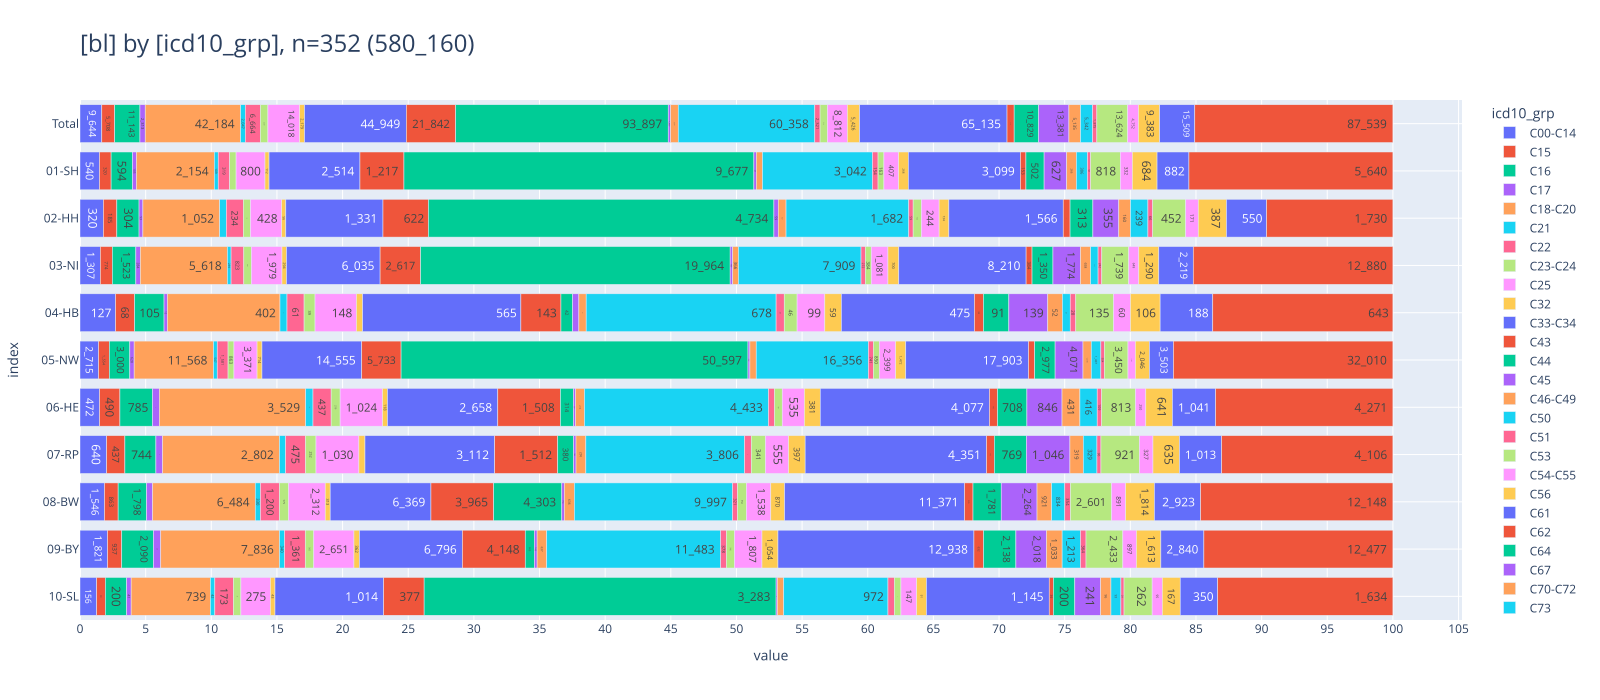

In [16]:
_alias = "z_icd10_3d"
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=True)
    .merge(dim_icd10_3d.to_df().set_index('code'), left_on=_alias, right_index=True, how="left")
    [["kkr", "code_kid", "cnt"]]
    .rename(columns={"kkr": "bl", "code_kid": "icd10_grp"})
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
)

<br>

### <a id='toc1_5_3_'></a>[Diagnosesicherung](#toc0_)
- **Filter: DJ = 2023, C44 und D-Diagnosen sind ausgeschlossen**

> 💡 `ZfKD`: _"auffällig ist der hohe Anteil an fehlenden Diagnosesicherungen in `08-BW`"_  
> 💡 `ZfKD`: _"keine DCO Markierungen für Fälle aus `05-NW`"_

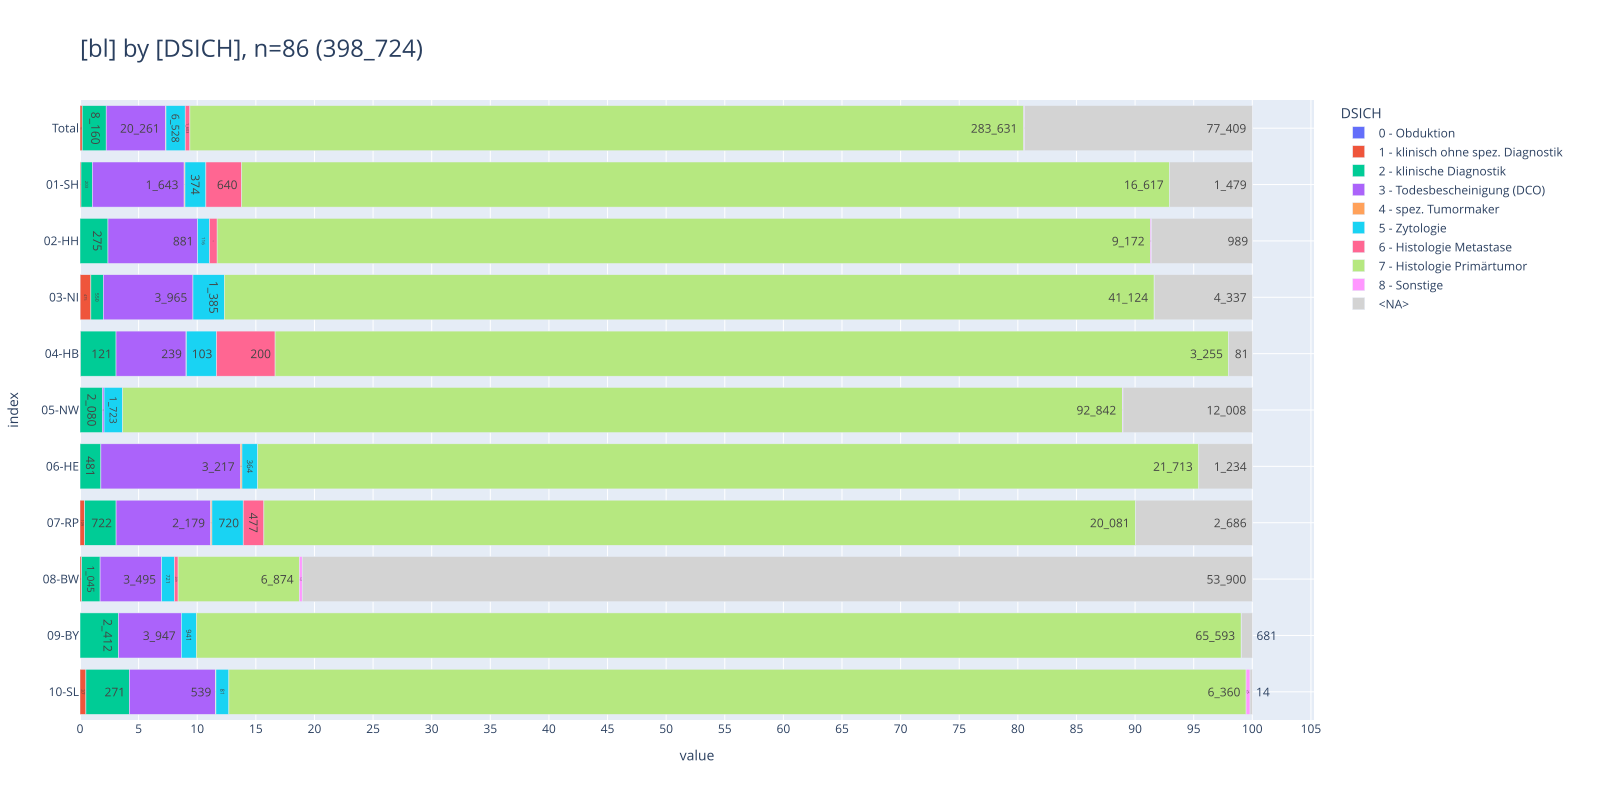

In [17]:
_alias = "DSICH"
_df = (
    show_freqs(alias=_alias)
    .merge(dim_dsich_epi, left_on=_alias, right_index=True, how="left")[
        ["kkr", "label", "cnt"]
    ]
    .rename(columns={"kkr": "bl", "label": _alias})
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=800,
)

<!-- <br>

### <a id='toc1_5_4_'></a>[DCO Diagramm](#toc0_)
- **Filter: DJ = 2020-2024, C44 und D-Diagnosen sind ausgeschlossen, GKZbl 01-16**
- die epi Variable `DCO` wird wie folgt gebildet:
  - 1 wenn Diagnosesicherung = 3
  - sonst 2 (auch für Diagnosesicherung missing)  -->

In [18]:
_df= (db_epi
    .filter("DJ between 2018 and 2024 and left(ICDGM10,3) <> 'C44' and left(ICDGM10,1) = 'C'")
    .filter("GKZbl::int <=16")
    .project("""--sql
        GKZbl, DCO, DJ
    """)
    #.filter("DSICH is null")
    .aggregate("DJ::text as DJ, DCO, GKZbl as bl, count(*) as cnt")
    .to_df()
)
_df["DCO"] = _df["DCO"].replace({1:"1 - yes", 2:"2 - no"})
# _df
# _=pls.plot_facet_stacked_bars(
#     _df,
#     subplot_size=600,
#     relative=True,
#     annotations=True,
#     # renderer=None,
# )

# tabelle non-dco -> icd10_3d, jahr ab 2018

In [19]:
# _df= (db_epi
#     .filter("DJ between 2018 and 2023 and left(ICDGM10,3) <> 'C44' and left(ICDGM10,1) = 'C'")
#     .filter("GKZbl::int <=16")
#     .project("""--sql
#         DCO, DJ
#     """)
#     #.filter("DSICH is null")
#     .aggregate("DJ::text as DJ, DCO, count(*) as cnt")
#     .order("DJ")
#     .to_df()
# )
# _df["DCO"] = _df["DCO"].replace({1:"1 - yes", 2:"2 - no"})
# _df
# # lol = tbl.pivot_df(_df, swap=True, data_bar_axis='x', total_axis="", pct_axis="")
# _df.to_excel("15-st.xlsx")
# # lol.to_excel("15-st_icd.xlsx")

### <a id='toc1_5_5_'></a>[DCO](#toc0_)
- **Filter: DJ = 2010-2024, GKZbl 01-16**
- Metrik: Anteil DCO an Gesamtfallzahl in %
<!-- > 💡 für 09-BY sind in dieser Lieferung erheblich weniger DCO Fälle festzustellen -->

In [20]:
_filter = """--sql
    bl::int between 1 and 16
    and z_dy::int between 2010 and 2024
    and z_icd10_3d not in ('C44','D04')
    and left(z_icd10_3d,1) = 'C'
"""

db_dco = con.sql(f"""--sql
    with t_all as (
        select  GKZbl as bl
                ,(DCO=1)::tinyint as is_dco
                ,case when IARC like '%A_Mehrfach%' then 1 else 0 end as is_multiple
                ,DJ as z_dy
                ,z_icd10_3d
        from    db_epi
    )
    --select * from t_all
    --where bl::int between 1 and 16
    select  bl, z_dy,
            count(*) as cnt,
            sum(is_dco) as sum_dco,
            sum(is_multiple) as sum_multiple,
            sum(is_dco) / cnt * 100 as pct_dco,
            sum(is_multiple) / cnt * 100 as pct_multiple,
    from    t_all
    where {_filter}
    group by all
    """)
# tbl.descr_db(db_dco, "dco data")

hlp.print_filter(_filter)

tbl.pivot_df(
    db_dco.project("bl, z_dy, pct_dco").to_df(),
    swap=True,
    precision=2,
    pct_axis="",
    total_axis="",
    font_size_th=13,
    font_size_td=11,
)

<!-- START_TOKEN -->

# filter

    bl::int between 1 and 16
    and z_dy::int between 2010 and 2024
    and z_icd10_3d not in ('C44','D04')
    and left(z_icd10_3d,1) = 'C'



<!-- END_TOKEN -->

bl,01,02,03,04,05,06,07,08,09,10,11,12,13,14,15,16
z_dy,,,,,,,,,,,,,,,,
2010,13.97,6.90,7.78,3.26,14.01,17.08,11.24,0,10.57,4.23,0,0,0,0,0,0
2011,14.29,4.89,7.40,4.24,11.95,16.62,14.04,0,9.62,4.11,0,0,0,0,0,0
2012,14.78,5.22,7.82,4.39,10.84,16.71,13.43,0,9.25,4.78,0,0,0,0,0,0
2013,13.84,5.09,6.90,6.15,10.80,17.75,15.68,0,8.73,6.42,0,0,0,0,0,0
2014,13.84,3.75,6.83,11.27,10.13,17.71,14.94,0.10,8.36,9.70,0,0,0,0,0,0
2015,13.64,4.08,6.79,7.11,9.59,17.71,10.68,6.11,8.40,8.02,0,0,0,0,0,0
2016,12.51,2.49,6.42,5.70,9.34,15.17,8.62,5.52,8.87,6.62,0,0,0,0,0,0
2017,10.49,3.01,6.19,5.97,8.21,14.45,5.49,4.71,8.13,6.83,0,0,0,0,0,0
2018,8.75,2.48,5.70,5.28,7.18,13.38,6.50,3.87,7.96,6.38,0,0,0,0,0,0


### <a id='toc1_5_6_'></a>[Anteil Mehrfachtumore](#toc0_)

In [21]:
tbl.pivot_df(
    db_dco.project("bl, z_dy, pct_multiple").to_df(),
    swap=True,
    precision=2,
    pct_axis="",
    total_axis="",
    font_size_th=13,
    font_size_td=11,
)

bl,01,02,03,04,05,06,07,08,09,10,11,12,13,14,15,16
z_dy,,,,,,,,,,,,,,,,
2010,0.07,0.47,0.28,0.02,0.05,0.15,0.13,0.25,0.01,1.77,0,0,0,0,0,0
2011,0.02,0.52,0.31,0.05,0.05,0.19,0.17,0.32,0.02,1.44,0,0,0,0,0,0
2012,0.01,0.43,0.30,0.10,0.06,0.15,0.22,0.27,0.01,1.97,0,0,0,0,0,0
2013,0.01,0.32,0.37,0.17,0.11,0.19,0.29,0.46,0.02,1.88,0,0,0,0,0,0
2014,0.01,0.45,0.40,0.21,0.17,0.19,0.37,0.53,0.02,3.41,0,0,0,0,0,0
2015,0.00,0.43,0.39,0.53,0.22,0.11,0.37,0.54,0.03,3.72,0,0,0,0,0,0
2016,0.21,0.40,0.39,0.56,0.34,0.08,0.50,0.56,0.04,3.41,0,0.95,0,0,0,0
2017,0.39,0.34,0.39,0.46,0.37,0.18,0.62,0.61,0.04,3.47,0,0,0,0,0,0
2018,0.33,0.37,0.46,0.50,0.25,0.21,0.43,0.63,0.08,3.34,0,0,2.38,0,0,0


<br>

### <a id='toc1_5_7_'></a>[Dignität](#toc0_)
- **Filter: DJ = 2020-2023, C44 und D-Diagnosen sind eingeschlossen**


In [22]:
# _alias = "DIG"
# _df = (
#     show_freqs(alias=_alias, incl_c44_and_d=False, db_list_dy="(2023)")
#     .merge(dim_dig, left_on=_alias, right_index=True, how="left")[
#         ["kkr", "label", "cnt"]
#     ]
#     .rename(columns={"kkr": "bl", "label": _alias})
# )
# _=pls.plot_stacked_bars(
#     _df,
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     # caption=caption_str(_alias, batch_max),
#     show_total=True,
#     height=600,
# )

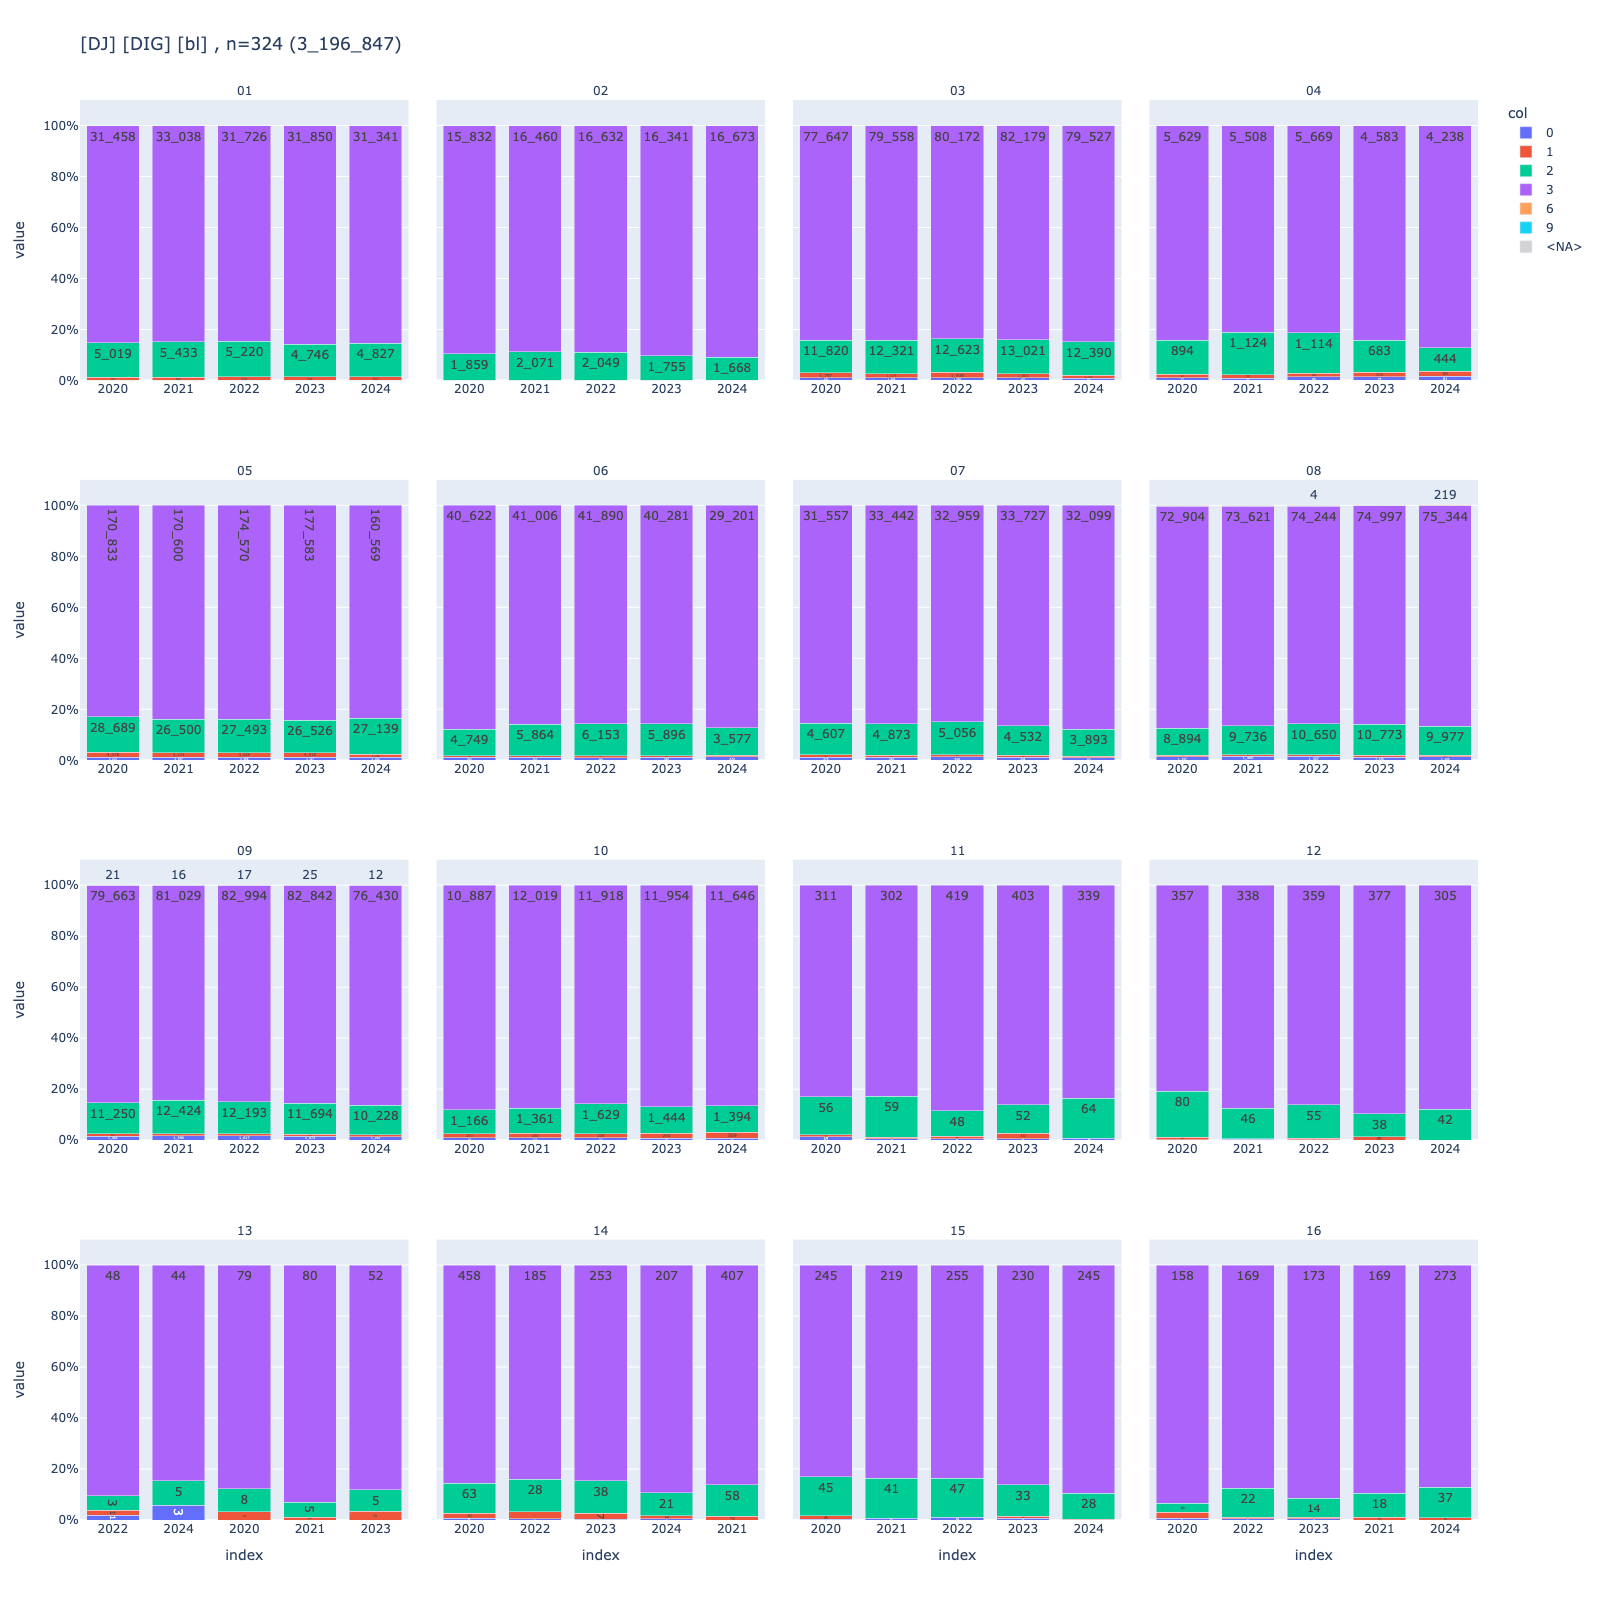

In [23]:
_df = (
    db_epi.filter("DJ between 2020 and 2024 and GKZbl::int <= 16")
    .aggregate("DJ::text as DJ, DIG::text as DIG, GKZbl as bl, count(*) as cnt")
    .to_df()
)
# _df
_ = pls.plot_facet_stacked_bars(
    _df,
    subplot_size=400,
    relative=True,
    annotations=True,
    sort_values_facet=True,
)

<br>

### <a id='toc1_5_8_'></a>[Grading 1](#toc0_)
- **Filter: DJ = 2024, C44 und D-Diagnosen sind ausgeschlossen**

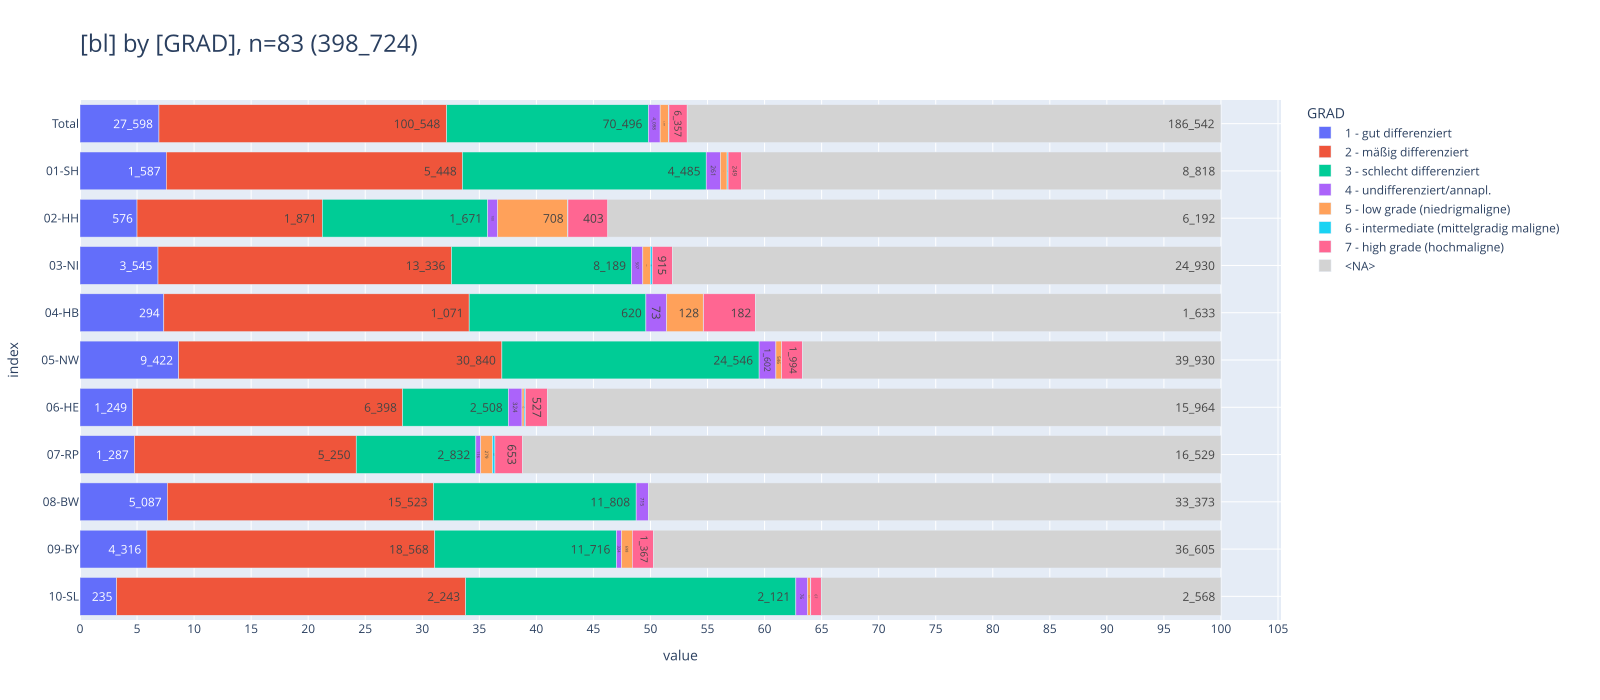

In [24]:
_alias='GRAD'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .merge(dim_grading_epi, left_on=_alias, right_index=True, how="left")[
        ["kkr", "label", "cnt"]
    ]
    .rename(columns={"kkr": "bl", "label": _alias})
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
)

### <a id='toc1_5_9_'></a>[Grading 2](#toc0_)
- **Filter: DJ = 2020-2024, kein DCO, gradingrelevante ICD10+HISC**


<!-- START_TOKEN -->

# filter

        DJ between 2020 and 2024
        and DCO = 2
        and (
        left(ICDGM10, 1) ='C' 
        and
            (
                right(left(ICDGM10,3), 2)::int8 between 00 and 33
                or right(left(ICDGM10,3), 2)::int8 between 50 and 57
                or right(left(ICDGM10,3), 2)::int8 between 63 and 68
                or right(left(ICDGM10,3), 2)::int8 = 60
            )
        and left(HISC,4)::int between 8010 and 8576
        and GKZbl::int between 1 and 16
        )



<!-- END_TOKEN -->

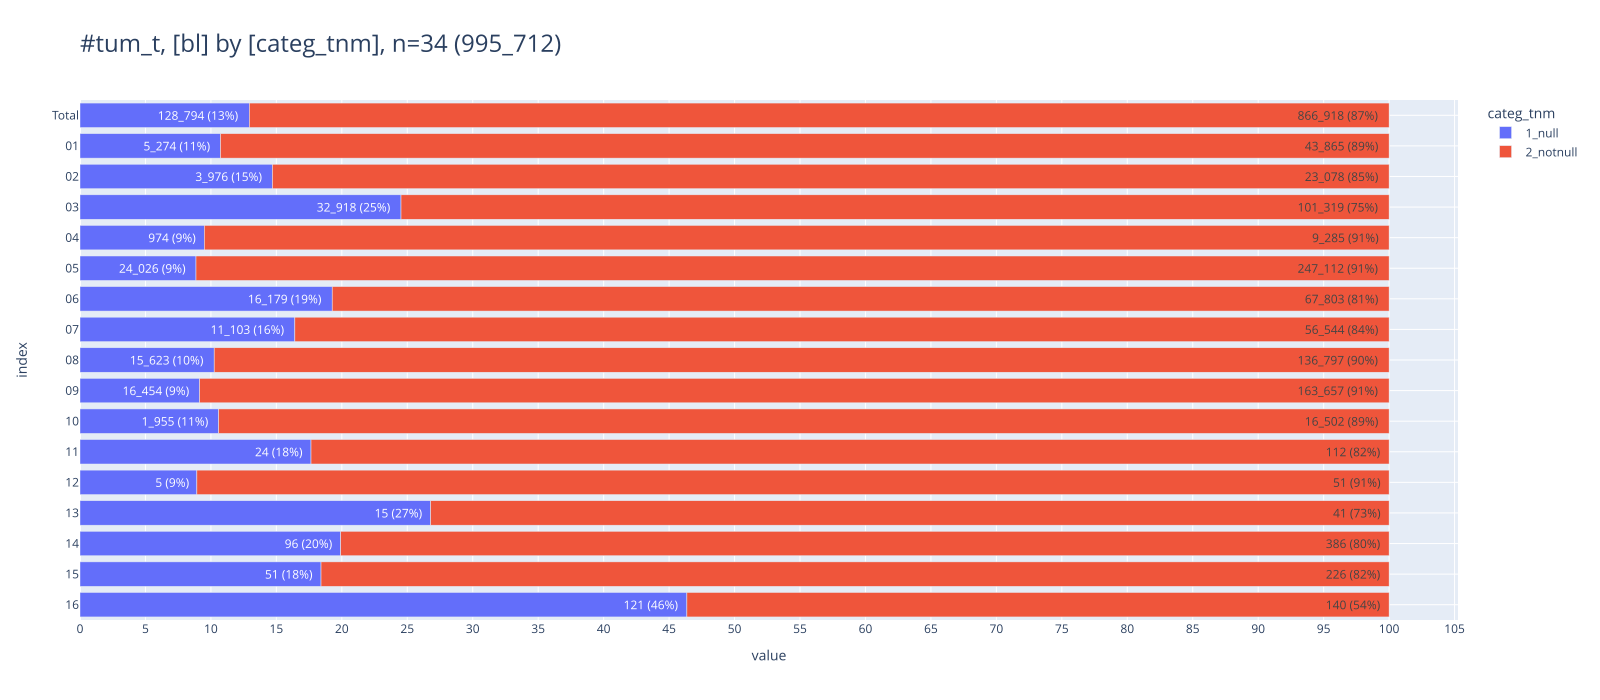

In [25]:
FILTER = """
        DJ between 2020 and 2024
        and DCO = 2
        and (
        left(ICDGM10, 1) ='C' 
        and
            (
                right(left(ICDGM10,3), 2)::int8 between 00 and 33
                or right(left(ICDGM10,3), 2)::int8 between 50 and 57
                or right(left(ICDGM10,3), 2)::int8 between 63 and 68
                or right(left(ICDGM10,3), 2)::int8 = 60
            )
        and left(HISC,4)::int between 8010 and 8576
        and GKZbl::int between 1 and 16
        )
"""
db_grad=con.sql(query=f"""--sql
    with t1 as (
        select
            GKZbl as bl,
            case
                when GRAD is null then '1_null'
                else '2_notnull' end as categ_tnm,
        from Tumor4
        where True
        and {FILTER}
    )
    select * from t1
""")

# tbl.descr_db(db_grad, "db_grad")

hlp.print_filter(FILTER)

pls.plot_stacked_bars(
    db_grad.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_t",
    height=700,
    width=1600,
    # kkr_col="z_kkr_label"
)


<br>

### <a id='toc1_5_10_'></a>[Altersgruppen](#toc0_)

- **Filter: DJ = 2024, C44 und D-Diagnosen sind ausgeschlossen**


In [26]:
# _alias='ALTGRP'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True, height=600)

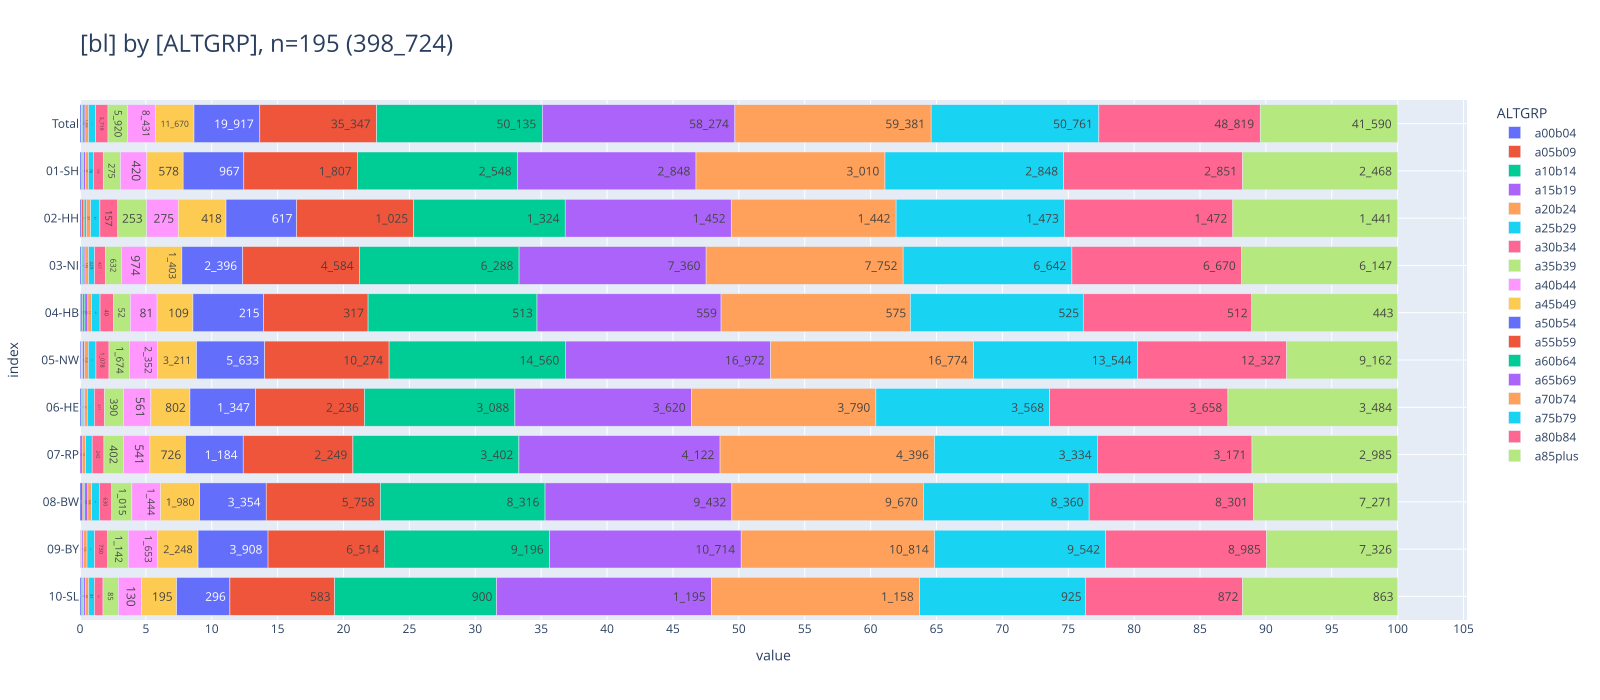

In [27]:
_alias='ALTGRP'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "ALTGRP", "cnt"]]
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
)

### <a id='toc1_5_11_'></a>[TNM](#toc0_)

<!-- START_TOKEN -->

# filter

        DJ between 2020 and 2024
        and DCO = 2
        and (
        left(ICDGM10, 1) ='C' and
            (
                right(left(ICDGM10,3), 2)::int8 between 00 and 43
                or right(left(ICDGM10,3), 2)::int8 between 45 and 69
                or right(left(ICDGM10,3), 2)::int8 between 73 and 75
            )
            and left(HISC,4)::int between 8010 and 8790
            and left(ICDGM10,3) not in ('C26', 'C39', 'C55')
            and ICDGM10 not in ('C140', 'C579', 'C639', 'C759')
        )
        and GKZbl::int between 1 and 16



<!-- END_TOKEN -->

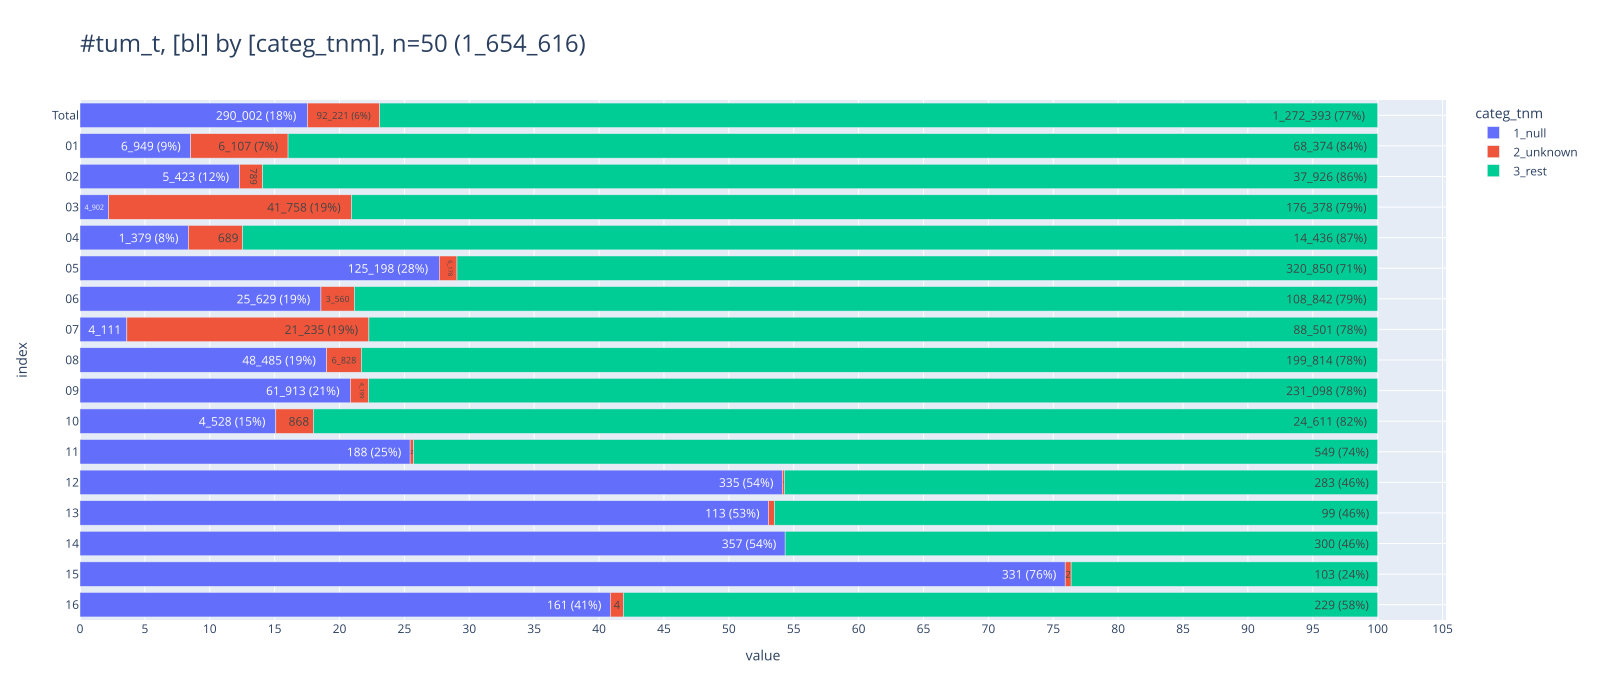

In [28]:
FILTER = """--sql
        DJ between 2020 and 2024
        and DCO = 2
        and (
        left(ICDGM10, 1) ='C' and
            (
                right(left(ICDGM10,3), 2)::int8 between 00 and 43
                or right(left(ICDGM10,3), 2)::int8 between 45 and 69
                or right(left(ICDGM10,3), 2)::int8 between 73 and 75
            )
            and left(HISC,4)::int between 8010 and 8790
            and left(ICDGM10,3) not in ('C26', 'C39', 'C55')
            and ICDGM10 not in ('C140', 'C579', 'C639', 'C759')
        )
        and GKZbl::int between 1 and 16
"""
db_tnm=con.sql(f"""--sql
    with t1 as (
        select
            GKZbl as bl,
            case 
                when TNMTKURZ is null then '1_null'
                when left(lower(TNMTKURZ),1) in ('x') then '2_unknown'
                else '3_rest' end as categ_tnm,
        from Tumor4
        where True
        and {FILTER}
    )
    select * from t1
""")

# tbl.descr_db(db_grad, "db_grad")
hlp.print_filter(FILTER)

pls.plot_stacked_bars(
    db_tnm.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_t",
    height=700,
    width=1600,
    # kkr_col="z_kkr_label"
)


<br>

### <a id='toc1_5_12_'></a>[UICC](#toc0_)
- **Filter: DJ = 2024, C44 und D-Diagnosen sind ausgeschlossen**
- die Variable `UICC` wird vom ZfKD gebildet

In [29]:
# _alias='UICC'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True, height=600 )

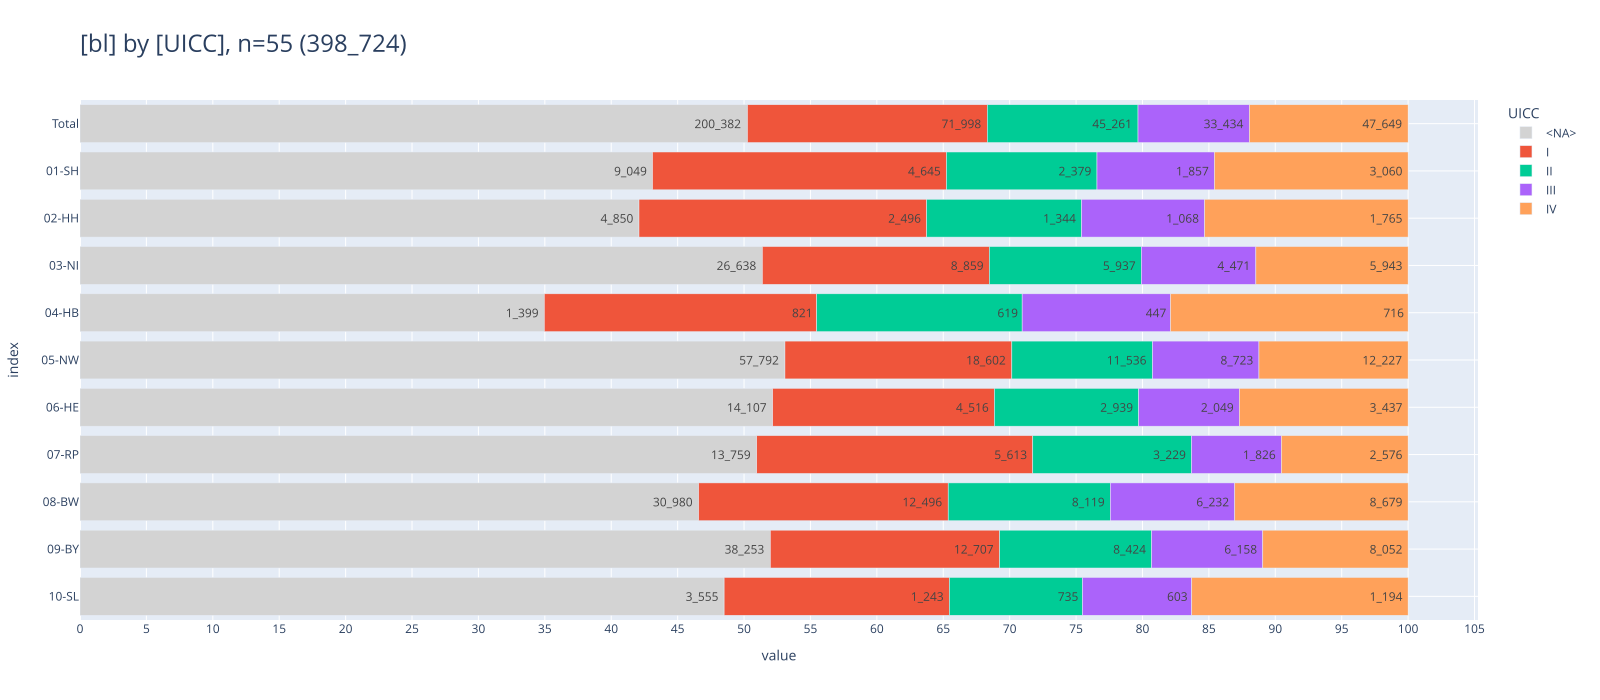

In [30]:
_alias='UICC'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "UICC", "cnt"]]
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
)

<br>

### <a id='toc1_5_13_'></a>[TNM-Auflage](#toc0_)
- **Filter: DJ = 2024, C44 und D-Diagnosen sind ausgeschlossen**
- nicht übermittelte Auflagen werden im ZfKD geschätzt und imputiert anhand des DJ, daher keine missings

> 💡 `ZfKD`: _"Auflage 7 nur noch von 03-NI in nennenswertem Umfang übermittelt"_

In [31]:
# _alias='TNMAUFL'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True,height=600 )

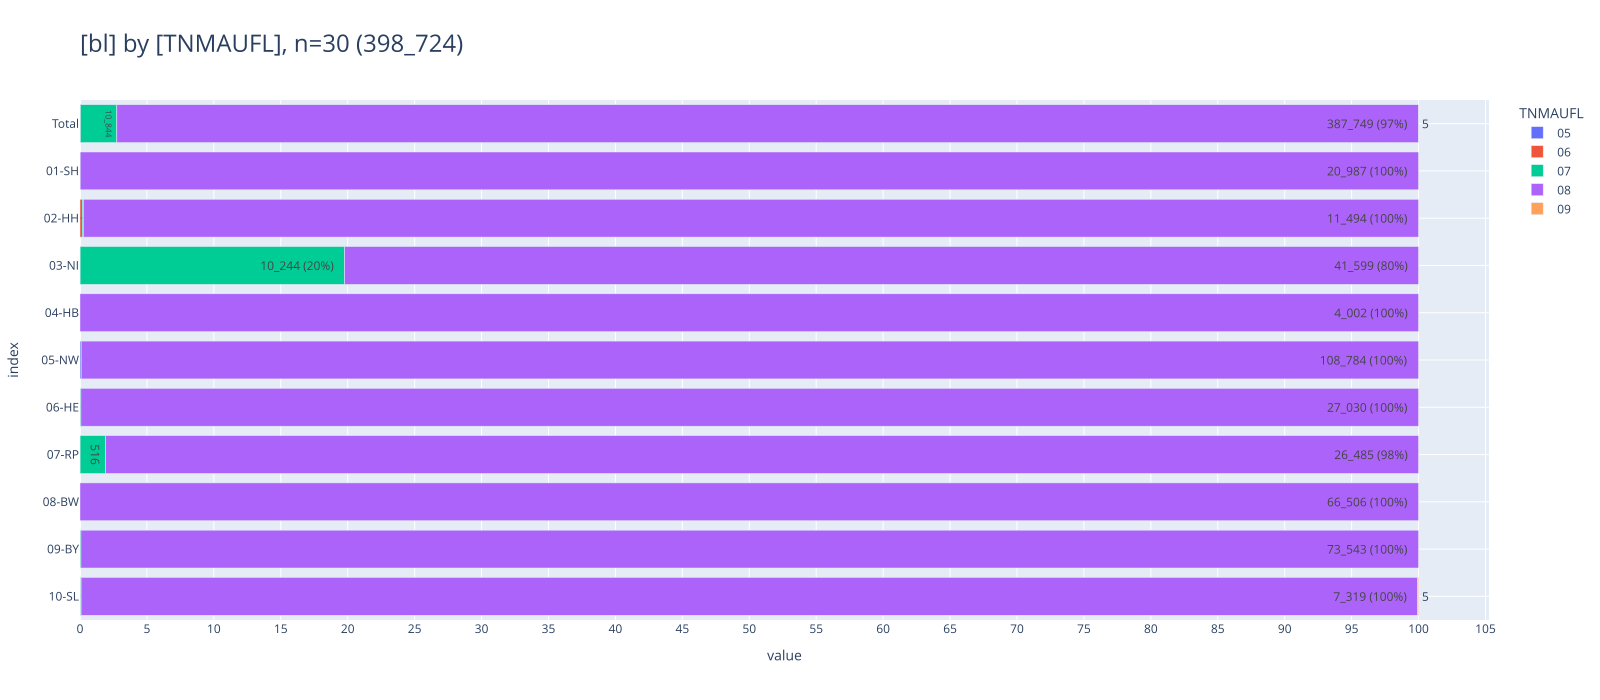

In [32]:
_alias='TNMAUFL'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "TNMAUFL", "cnt"]]
)
_df["TNMAUFL"] = _df["TNMAUFL"].astype(str).str.zfill(2)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
)

# todo regel ergänzen für imputation

<br>

### <a id='toc1_5_14_'></a>[Tod](#toc0_)

#### <a id='toc1_5_14_1_'></a>[Verteilung der Variable TOD im verarbeiteten Datensatz](#toc0_)
- **Filter: DJ = 2024, C44 und D-Diagnosen sind ausgeschlossen**

In [33]:
# _alias='TOD'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _df["Wert"] = _df["Wert"].replace({"1":"1 - Ja", "2":"2 - Nein"})
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True, height=600)

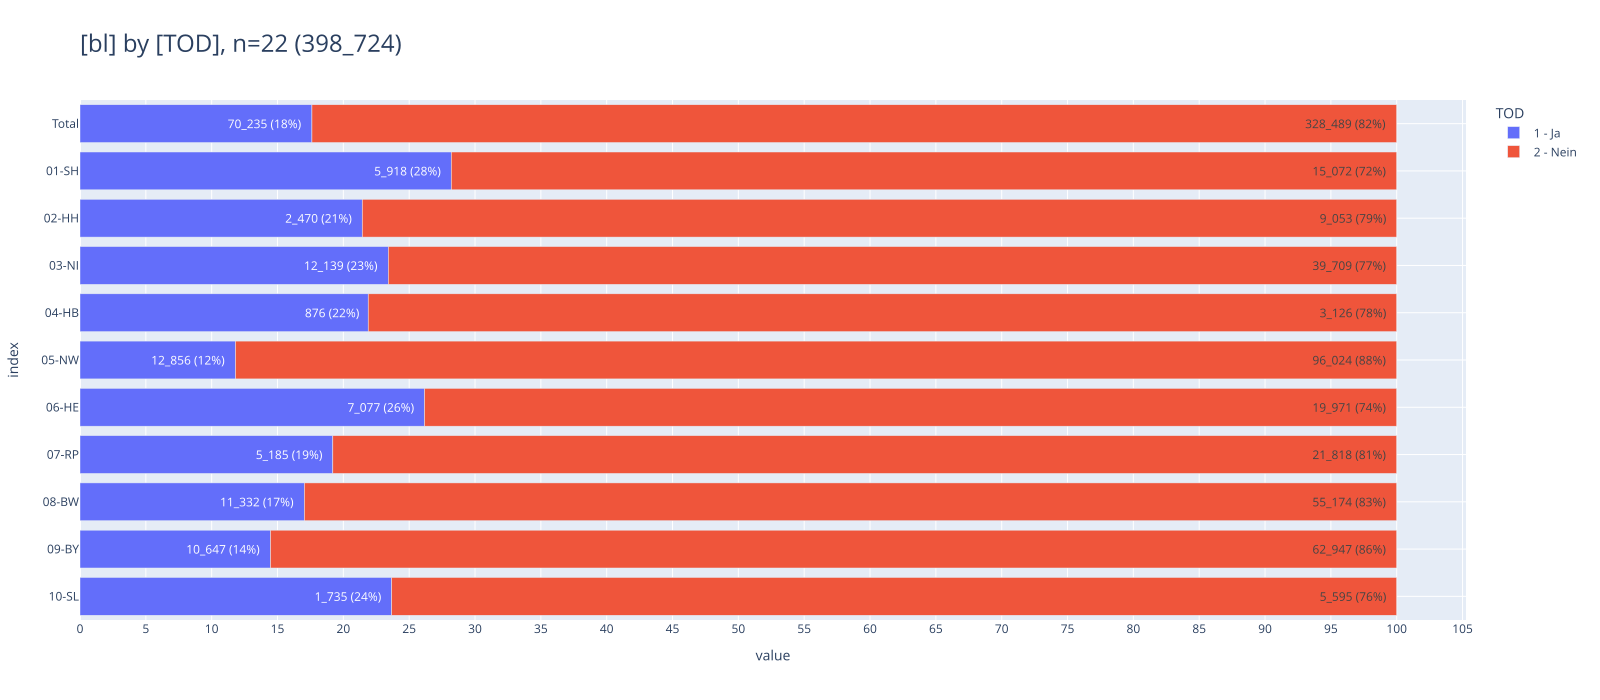

In [34]:
_alias='TOD'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "TOD", "cnt"]]
)
_df["TOD"] = _df["TOD"].replace({1:"1 - Ja", 2:"2 - Nein"})
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=True,
    relative=True,
    dropna=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
    )
# todo kurz erklären

<br>

#### <a id='toc1_5_14_2_'></a>[Verteilung der Variable TOD in den original gelieferten Daten](#toc0_)
- Grundgesamtheit: alle Daten mit DJ > 1970
- neben `J` und `N` sind diverse Formen von Leerkodierungen unterschieden (`NULL`, `''`, `' '` etc.)
- die Daten den Registern ohne missings enthalten eine eindeutige Information zu `TOD`
- bei allen sonstigen EKR wird angenommen: Todesangabe leer -> lebend

In [35]:
_df = (con.from_df(df_freqs)
    .filter(f"Alias = 'TOD' and Stufe = 2 and BatchID = {batch_max}")
    .project("""--sql
            Alias,EKRNR, Anzahl,
            case when trim(ifnull(Wert,'')) = '' then '<NA>' else Wert end as Wert
            """)
    .to_df()
    .pivot_table(
        index="Wert",
        columns="EKRNR",
        values="Anzahl",
        aggfunc="sum",
        fill_value=0,
        dropna=False,
    )
)
tbl.show_num_df(
    _df,
    total_axis="xy",
    data_bar_axis="x",
    font_size_th=13,
    font_size_td=11,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,Total
Wert,,,,,,,,,,,
,388_312,0,880_262,69_072,0,451_264,0,716_675,931_269,0,3_436_854
J,435_819,268_739,1_126_845,93_864,2_055_667,559_243,524_226,542_501,1_098_825,291_723,6_997_452
N,0,193_826,0,0,2_348_618,0,379_563,0,0,137_293,3_059_300
Total,824_131,462_565,2_007_107,162_936,4_404_285,1_010_507,903_789,1_259_176,2_030_094,429_016,13_493_606


### <a id='toc1_5_15_'></a>[Verteilung Todesursachen nach ICDT10](#toc0_)
- gezählt sind **Personen**
- **Filter: `SJ` >= 2010**
- `icdt10_1d` gibt die erste Stelle der Todesursache an
- ⚠️ für `01-SH` und `02-HH` sind die DJ nicht in korrekter Reihenfolge

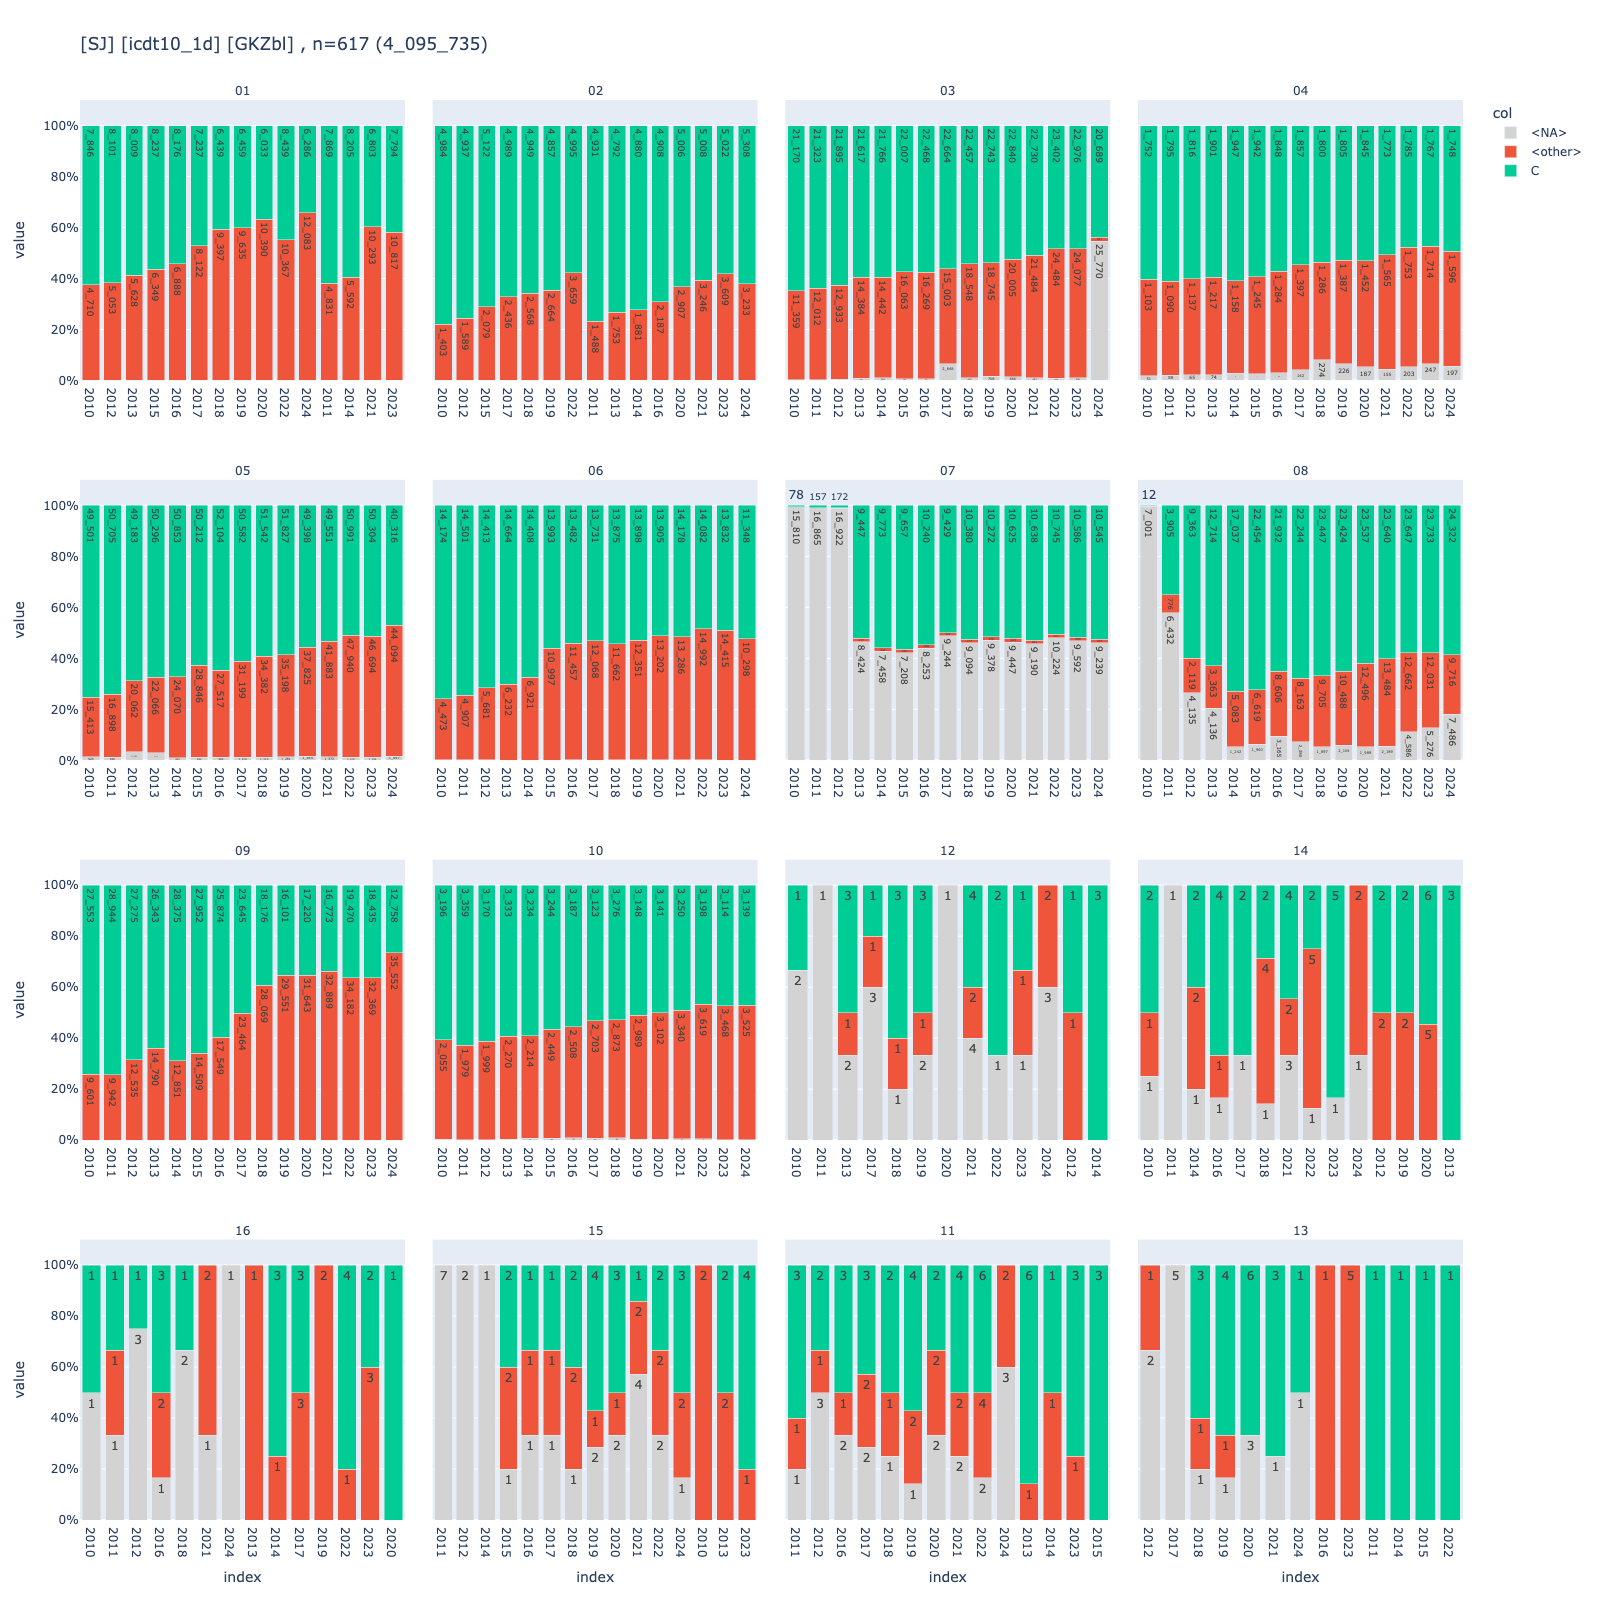

In [36]:
df_tu2 = (db_epi
    .project("""--sql
            year(SDIMP)::text as SJ, 
            ICDT10, 
            GKZbl, 
            case when ifnull(ICDT10,'') = '' then null when upper(left(ICDT10,1)) = 'C' then 'C' else '<other>' end as icdt10_1d, 
            GLOBALPATID
            """)
    .filter("SJ::int >= 2010 and GKZbl::int <= 16")
    .aggregate("""--sql
            SJ, icdt10_1d, GKZbl
            ,count(distinct GLOBALPATID) as cnt_pat
            --,count(*) as cnt
    """)
    .order("SJ")
    .to_df()
)

_ = pls.plot_facet_stacked_bars(
    df_tu2,
    # df_tu[["SJ","icdt10_1d","GKZbl"]],
    # df_tu[["DJ","ICDT10","EKRNR"]],
    # top_n_color=5,
    subplot_size=400,
    # sort_values_facet=True,
    # sort_values_index=True,
    relative=True,
    annotations=True,
)

<div style="page-break-after: always;"></div>

## <a id='toc1_6_'></a>[Plausibilitätsprüfungen](#toc0_)
- **Filter**
  - **es ist jeweils nur das aktuellste DJ berücksichtigt (aktuell: 2024, ins letzter Lieferung: 2023)**
- Die Tabellen sind zur besseren Lesbarkeit nun aufgeteilt nach den Plausibilitätsprüfungen ([pdf](https://www.krebsregisterverbund.de/attachments/download/8743/Plausibilit%C3%A4tspr%C3%BCfungen_details.pdf))
  - `A`: Fälle ausgeschlossen
  - `B`: Fälle markiert
  - `C`: Fälle korrigiert
- Spalten
  - `cnt_epi2024`: Absolute Fallzahl der checks für das in diesem Datensatz höchste DJ (2023)
  - `cnt_now`: Absolute Fallzahl der checks für das im aktuellen Datensatz höchsten DJ (2024)
  - `pct_epi2024`: Anteil Fallzahl der checks an allen Fällen für das in diesem Datensatz höchste DJ (2023)
  - `pct_now`: Anteil Fallzahl der checks an allen Fällen für das im aktuellen Datensatz höchste DJ (2024)
  - _(Absolute Fallzahlen = nach Abzug der A-Prüfungen)_

In [37]:
# def show_checks(df: pd.DataFrame, batches: list, reg: str, relative: bool = False) -> None:
#     df=df.loc[
#         (df['BatchID'].isin(batches))
#         & (df['EKRNR'] == reg)
#         & (df['DJahr'] != 'alt')
#         ,['BatchID','check_label','Anzahl']]
#     # display(df)
#     df1 = (df[df["check_label"].str.endswith("[48]")])[["BatchID", "Anzahl"]]
#     df2 = df.merge(df1, on="BatchID")
#     df2["pct"] = round(df2["Anzahl_x"] / df2["Anzahl_y"] * 100,1)
#     if relative:
#         df2 = df2[["BatchID", "check_label", "pct"]]
#     else:
#         df2 = df2[["BatchID", "check_label", "Anzahl_x"]]
#     # display(df2)
#     display(tbl.pivot_df(df2, swap=True, data_bar_axis='x', total_axis="", pct_axis=""))

# batches=[376,385,batch_max]
# ekr_epi2023=sorted(df_checks[df_checks.BatchID>385].EKRNR.unique())

In [38]:
def show_checks2(df_in: pd.DataFrame, reg: str) -> None:
    
    db = con.from_df(df_in)
    db_total= con.sql(f"""--sql
        select *
        from db
        where BatchID = {batch_max}
        and EKRNR = '{reg}'
        and DJahr <> 'alt'
    """)
    
    
    if db_total.count("*").fetchone()[0] == 0:
        print("❌")
        return

    def get_ser(
        df_in: pd.DataFrame, batch_id: int, reg: str, suffix: str
    ) -> pd.DataFrame:
        df = df_in.copy()

        total = df.loc[
            (df["BatchID"] == batch_id)
            & (df["EKRNR"] == reg)
            & (df["DJahr"] != "alt")
            & (df["check_label"] == "I_Fallzahl[48]"),
            ["BatchID", "check_label", "Anzahl"],
        ].iloc[0, -1]

        df_out = df.loc[
            (df["BatchID"] == batch_id) & (df["EKRNR"] == reg) & (df["DJahr"] != "alt"),
            ["BatchID", "check_label", "Anzahl"],
        ]

        df_out["pct"] = df_out["Anzahl"] / total * 100
        return (
            df_out.rename(columns={"Anzahl": "cnt_" + suffix, "pct": "pct_" + suffix})
            .iloc[:, 1:]
            .reset_index(drop=True)
        )

    df0 = get_ser(df_checks, 418, reg, "epi2024")
    df1 = get_ser(df_checks, batch_max, reg, "now")

    df = (
        pd.merge(df0, df1, on="check_label", how="outer")
        .set_index("check_label")
        .iloc[:, [0, 2, 1, 3]]
    )
    df_ab = df[df.index.str.startswith(("A_", "B_","I_"))]
    df_a = df[df.index.str.startswith(("A_","I_"))]
    df_b = df[df.index.str.startswith(("B_","I_"))]
    df_c = df[df.index.str.startswith(("C_","I_"))]
    display(tbl.show_num_df(df_a, total_axis="", data_bar_axis="x", col1_width=300,font_size_th=13,font_size_td=11,))
    display(tbl.show_num_df(df_b, total_axis="", data_bar_axis="x", col1_width=300,font_size_th=13,font_size_td=11,))
    display(tbl.show_num_df(df_c, total_axis="", data_bar_axis="x", col1_width=300,font_size_th=13,font_size_td=11,))
    return

<br>

### <a id='toc1_6_1_'></a>[ ⚠️ 01-SH](#toc0_)
- `B_TOD_Ja_Aber_Kein_SJ`: 0 -> 4%
- alle Fälle wurden korrigiert laut `C_TOD=1_korrigiert_aufgrund_Sterbeangaben`

In [39]:
# show_checks(df_checks, batches=batches, reg='01-SH', relative=False)
show_checks2(df_checks, "01-SH")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_SEX_fehlerhaft[66],1,nan,0,nan
A_ICD10_keineAuswertung[54],1,nan,0,nan
A_Mehrfachmeldung[37],121,132,0,0
I_Fallzahl[48],34_512,36_307,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],12,14,0,0
B_DCO_DDIMP_inkonsistent[39],8,8,0,0
B_DIG_HISC_unplausibel[70],44,53,0,0
B_DIG_ICDO3_unplausibel[69],nan,1,nan,0
B_DSICH_HISC_unplausibel[72],130,102,0,0
B_Entscheidung_Mehrfachtumor_unplausibel[82],4,9,0,0
B_GRAD_HISC_unplausibel[85],44,45,0,0
B_HISC_ICDO3_unplausibel[55],222,209,1,1
B_TNMM_GROBST_unplausibel[78],109,95,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],2,4,0,0
C_HISC_korrigiert[56],5,7,0,0
C_ICD10DREI_korrigiert[80],156,192,0,1
C_ICDO3_korrigiert[52],43,43,0,0
C_LOKS_korrigiert[84],137,194,0,1
C_SJ>MaxJahr[14],2_555,nan,7,nan
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],nan,1_511,nan,4
I_Fallzahl[48],34_512,36_307,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_2_'></a>[✅ 02-HH](#toc0_)

In [40]:
# show_checks(df_checks, batches=batches, reg='02-HH', relative=True)
show_checks2(df_checks, "02-HH")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_Mehrfachmeldung[37],176,136,1,1
A_SEX_fehlerhaft[1],1,4,0,0
I_Fallzahl[48],18_011,17_987,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],6,9,0,0
B_DCO_DDIMP_inkonsistent[39],33,25,0,0
B_DIG_HISC_unplausibel[70],197,169,1,1
B_DSICH_HISC_unplausibel[72],243,250,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],nan,4,nan,0
B_GRAD_HISC_unplausibel[85],19,20,0,0
B_HISC_ICDO3_unplausibel[55],318,269,2,1
I_Fallzahl[48],18_011,17_987,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DJ_korrigiert_aufgrund_DSICH[43],81,76,0,0
C_HISC_korrigiert[56],6,16,0,0
C_ICD10DREI_korrigiert[80],58,57,0,0
C_ICDO3_korrigiert[52],2,3,0,0
C_LOKS_korrigiert[84],216,237,1,1
I_Fallzahl[48],18_011,17_987,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_3_'></a>[✅ 03-NI](#toc0_)

In [41]:
# show_checks(df_checks, batches=batches, reg='03-NI', relative=False)
show_checks2(df_checks, "03-NI")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],147,147,0,0
A_Mehrfachmeldung[37],1_256,2_010,1,2
A_Zeitangaben_fehlerhaft[58],2,7,0,0
I_Fallzahl[48],86_331,84_692,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],35,55,0,0
B_DCO_DDIMP_inkonsistent[39],101,90,0,0
B_DIG_HISC_unplausibel[70],420,386,0,0
B_DSICH_HISC_unplausibel[72],697,704,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],1,1,0,0
B_GRAD_HISC_unplausibel[85],125,136,0,0
B_HISC_ICDO3_unplausibel[55],1_175,1_092,1,1
B_PatAngaben_inkonsistent[60],2,12,0,0
B_TNMM_GROBST_unplausibel[78],2,3,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],nan,15,nan,0
C_DJ_korrigiert_aufgrund_DSICH[43],7,11,0,0
C_HISC_korrigiert[56],558,289,1,0
C_ICD10DREI_korrigiert[80],1_235,1_983,1,2
C_LOKS_korrigiert[84],516,378,1,0
C_SJ>MaxJahr[14],6_518,6_002,8,7
C_TNMx_korrigiert[44],166,121,0,0
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],5,39,0,0
I_Fallzahl[48],86_331,84_692,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_4_'></a>[✅ 04-HB](#toc0_)

In [42]:
# show_checks(df_checks, batches=batches, reg='04-HB', relative=False)
# show_checks(df_checks, batches=batches, reg='04-HB', relative=True)
show_checks2(df_checks, "04-HB")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],4,5,0,0
A_Mehrfachmeldung[37],25,14,0,0
A_SEX_fehlerhaft[1],2,nan,0,nan
I_Fallzahl[48],5_068,4_687,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],6,6,0,0
B_DCO_DDIMP_inkonsistent[39],4,2,0,0
B_DIG_HISC_unplausibel[70],34,85,1,2
B_DSICH_HISC_unplausibel[72],48,32,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],1,1,0,0
B_GRAD_HISC_unplausibel[85],12,8,0,0
B_HISC_ICDO3_unplausibel[55],85,114,2,2
B_TNMT_DIG_unplausibel[20],5,3,0,0
B_TNMx_ICD10_unplausibel[76],nan,5,nan,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],nan,1,nan,0
C_HISC_korrigiert[56],3,9,0,0
C_ICD10DREI_korrigiert[80],16,13,0,0
C_ICDO3_korrigiert[52],4,nan,0,nan
C_LOKS_korrigiert[84],81,69,2,1
I_Fallzahl[48],5_068,4_687,100,100


In [43]:
# print(f"{np.array(db_epi.columns)}")
# db_epi.filter("EKRNR = '04' and DJ = '2022'").value_counts("IARC")
# db_epi.filter("EKRNR = '04' and DJ = '2022' and IARC like '%1_korrigiert_aufgrund_Sterbeangaben%'").project("TOD, SDIMP")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_5_'></a>[⚠️ 05-NW](#toc0_)
- unverändert hohe werte bei `A_EKRNR_GKZ_unplausibel`
- Fallzahl DJ=2024 geringer

In [44]:
# show_checks(df_checks, batches=batches, reg='05-NW', relative=True)
show_checks2(df_checks, "05-NW")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_EKRNR_GKZ_unplausibel[83],21_338,22_483,11,12
A_ICD10_keineAuswertung[54],748,682,0,0
A_Mehrfachmeldung[37],255,216,0,0
I_Fallzahl[48],202_655,191_487,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],99,81,0,0
B_DALT_unplausibel[77],nan,1,nan,0
B_DCO_DDIMP_inkonsistent[39],38,2,0,0
B_DIG_HISC_unplausibel[70],2_026,2_053,1,1
B_DSICH_HISC_unplausibel[72],1_565,1_611,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],16,11,0,0
B_GRAD_HISC_unplausibel[85],121,89,0,0
B_HISC_ICDO3_unplausibel[55],2_767,2_910,1,2
B_PatAngaben_inkonsistent[60],1,nan,0,nan


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],527,368,0,0
C_ICD10DREI_korrigiert[80],636,387,0,0
C_ICDO3_korrigiert[52],130,88,0,0
C_LOKS_korrigiert[84],117,184,0,0
C_SJ>MaxJahr[14],15_419,9_680,8,5
C_TNMx_korrigiert[44],1,nan,0,nan
I_Fallzahl[48],202_655,191_487,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_6_'></a>[🚨 06-HE](#toc0_)
- Fallzahl DJ=2024 deutlich geringer

In [45]:
# show_checks(df_checks, batches=batches, reg='06', relative=True)
show_checks2(df_checks, "06-HE")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],1,2,0,0
A_Mehrfachmeldung[37],114,57,0,0
A_SEX_fehlerhaft[1],nan,3,nan,0
I_Fallzahl[48],44_073,31_633,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],30,22,0,0
B_DALT_unplausibel[77],1,nan,0,nan
B_DCO_DDIMP_inkonsistent[39],55,28,0,0
B_DIG_HISC_unplausibel[70],285,189,1,1
B_DIG_ICDO3_unplausibel[69],nan,1,nan,0
B_DSICH_HISC_unplausibel[72],560,405,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],6,10,0,0
B_GRAD_HISC_unplausibel[85],47,27,0,0
B_HISC_ICDO3_unplausibel[55],709,476,2,2


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],1,1,0,0
C_HISC_korrigiert[56],43,27,0,0
C_ICD10DREI_korrigiert[80],203,105,0,0
C_ICDO3_korrigiert[52],43,22,0,0
C_LOKS_korrigiert[84],178,100,0,0
C_SJ>MaxJahr[14],3_710,1_441,8,5
I_Fallzahl[48],44_073,31_633,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_7_'></a>[✅ 07-RP](#toc0_)

In [46]:
# show_checks(df_checks, batches=batches, reg='07-RP', relative=True)
show_checks2(df_checks, "07-RP")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_Mehrfachmeldung[37],184,221,1,1
I_Fallzahl[48],30_000,31_489,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],12,17,0,0
B_DCO_DDIMP_inkonsistent[39],24,20,0,0
B_DIG_HISC_unplausibel[70],240,177,1,1
B_DSICH_HISC_unplausibel[72],563,566,2,2
B_Entscheidung_Mehrfachtumor_unplausibel[82],11,7,0,0
B_GRAD_HISC_unplausibel[85],9,9,0,0
B_HISC_ICDO3_unplausibel[55],545,477,2,2
B_TNMx_ICD10_unplausibel[76],24,25,0,0
I_Fallzahl[48],30_000,31_489,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],284,261,1,1
C_ICD10DREI_korrigiert[80],202,187,1,1
C_ICDO3_korrigiert[52],16,25,0,0
C_LOKS_korrigiert[84],777,892,3,3
C_SJ>MaxJahr[14],2_047,1_677,7,5
C_TNMx_korrigiert[44],nan,2,nan,0
I_Fallzahl[48],30_000,31_489,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_8_'></a>[✅ 08-BW](#toc0_)

In [47]:
# show_checks(df_checks, batches=batches, reg='08-BW', relative=True)
show_checks2(df_checks, "08-BW")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],427,349,1,0
A_Mehrfachmeldung[37],444,486,1,1
A_SEX_fehlerhaft[1],6,10,0,0
A_Zeitangaben_fehlerhaft[58],9,13,0,0
I_Fallzahl[48],81_320,82_957,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],56,65,0,0
B_DCO_DDIMP_inkonsistent[39],16,30,0,0
B_DIG_HISC_unplausibel[70],1_024,1_149,1,1
B_DSICH_HISC_unplausibel[72],515,502,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],22,31,0,0
B_GRAD_HISC_unplausibel[85],89,98,0,0
B_HISC_ICDO3_unplausibel[55],1_745,1_938,2,2
B_PatAngaben_inkonsistent[60],2,1,0,0
B_TNMT_DIG_unplausibel[20],139,140,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],2,nan,0,nan
C_DJ_korrigiert_aufgrund_DSICH[43],6,1,0,0
C_HISC_korrigiert[56],133,153,0,0
C_ICD10DREI_korrigiert[80],471,684,1,1
C_ICDO3_korrigiert[52],27,63,0,0
C_LOKS_korrigiert[84],515,539,1,1
C_SJ>MaxJahr[14],1_018,2_785,1,3
I_Fallzahl[48],81_320,82_957,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_9_'></a>[✅ 09-BY](#toc0_)

In [48]:
# show_checks(df_checks, batches=batches, reg='09-BY', relative=True)
show_checks2(df_checks, "09-BY")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_keineAuswertung[54],232,188,0,0
A_Mehrfachmeldung[37],86,140,0,0
A_SEX_fehlerhaft[1],7,1,0,0
I_Fallzahl[48],84_717,86_674,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],42,51,0,0
B_DCO_DDIMP_inkonsistent[39],16,54,0,0
B_DIG_HISC_unplausibel[70],271,307,0,0
B_DSICH_HISC_unplausibel[72],476,666,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],2,5,0,0
B_GRAD_HISC_unplausibel[85],81,83,0,0
B_HISC_ICDO3_unplausibel[55],729,836,1,1
B_TNMM_GROBST_unplausibel[78],43,19,0,0
B_TNMT_DIG_unplausibel[20],7,8,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_HISC_korrigiert[56],59,69,0,0
C_ICD10DREI_korrigiert[80],229,225,0,0
C_ICDO3_korrigiert[52],55,60,0,0
C_LOKS_korrigiert[84],3_535,1_324,4,2
C_SJ>MaxJahr[14],3_707,4_051,4,5
I_Fallzahl[48],84_717,86_674,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_10_'></a>[⚠️ 10-SL](#toc0_)
- `A_Mehrfachmeldung` leicht erhöht mit 4%

In [49]:
# show_checks(df_checks, batches=batches, reg='10-SL', relative=True)
show_checks2(df_checks, "10-SL")

,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
A_ICD10_SEX_fehlerhaft[66],1,1,0,0
A_ICD10_keineAuswertung[54],18,13,0,0
A_Mehrfachmeldung[37],239,510,2,4
I_Fallzahl[48],11_076,12_247,100,100


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],9,4,0,0
B_DCO_DDIMP_inkonsistent[39],16,14,0,0
B_DIG_HISC_unplausibel[70],50,41,0,0
B_DSICH_HISC_unplausibel[72],136,174,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],3,3,0,0
B_GRAD_HISC_unplausibel[85],14,16,0,0
B_HISC_ICDO3_unplausibel[55],175,148,2,1
B_PatAngaben_inkonsistent[60],nan,2,nan,0
B_TNMT_DIG_unplausibel[20],9,10,0,0


,cnt_epi2024,cnt_now,pct_epi2024,pct_now
check_label,,,,
C_DIG_korrigiert[64],27,21,0,0
C_DJ_korrigiert_aufgrund_DSICH[43],3,6,0,0
C_HISC_korrigiert[56],49,46,0,0
C_ICD10DREI_korrigiert[80],110,118,1,1
C_ICDO3_korrigiert[52],4,12,0,0
C_LOKS_korrigiert[84],26,53,0,0
C_SJ>MaxJahr[14],71,69,1,1
I_Fallzahl[48],11_076,12_247,100,100


<div style="page-break-after: always;"></div>

### <a id='toc1_6_11_'></a>[✅ 11-GKR (ehemals)](#toc0_)

In [50]:
# show_checks(df_checks, batches=batches, reg='11-GKR', relative=True)
show_checks2(df_checks, "11-GKR")

❌


In [51]:
if False:
    df_pivot = (db_epi
        .filter("GKZbl::int <= 16")
        # .project("")
        .project("""
                GKZbl, DJ::text as DJ, is_deleted::bool as is_deleted, IARC, DCO
                ,case when IARC like '%A_Mehr%' then true else false end as is_multiple
                ,case when IARC like '%A_ICD10_keineAuswertung%' then true else false end as has_wrong_icd10
            """)
        .aggregate("GKZbl, DJ, is_deleted, IARC, DCO, count(*) as cnt, is_multiple, has_wrong_icd10")
        .to_df()
    )
    spec = "config/epi_pygwalker_spec.json"
    hlp.add_measures_to_pyg_config(spec, nodes=[("cnt_tum","sum(cnt)")])

    import pygwalker as pyg

    pyg.walk(df_pivot, appearance=os.getenv("THEME"), kernel_computation=True, spec=spec)

In [52]:
# _df = db_epi.filter("IARC like '%A_ICD10_keineAuswertung%' and EKRNR = '11' and DJ > '2016'").aggregate("cast(DJ as varchar) as DJ, count(DJ) as cnt").order("DJ").to_df()
# print("Auswertung Fallzahlen für den Test A_ICD10_keineAuswertung[54] für DJ vor und nach 2020: vor 2020 gibt es keine Auffälligkeiten")
# _=pls.plot_bars(_df, height=500, width=600, caption="[54] DJ um 2020")

In [53]:
# con.close()